# ----> Importer les bibliothèques

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ---->Charger les données

In [42]:
df_original=pd.read_csv('../data/cleveland.data',header=None,na_values='?')
df=df_original.copy()

In [43]:
df.columns = [
    'age',
    'sex',
    'cp',
    'trestbps',
    'chol',
    'fbs',
    'restecg',
    'thalach',
    'exang',
    'oldpeak',
    'slope',
    'ca',
    'thal',
    'target'
]

In [44]:
df.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [45]:
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
298,45.0,1.0,1.0,110.0,264.0,0.0,0.0,132.0,0.0,1.2,2.0,0.0,7.0,1
299,68.0,1.0,4.0,144.0,193.0,1.0,0.0,141.0,0.0,3.4,2.0,2.0,7.0,2
300,57.0,1.0,4.0,130.0,131.0,0.0,0.0,115.0,1.0,1.2,2.0,1.0,7.0,3
301,57.0,0.0,2.0,130.0,236.0,0.0,2.0,174.0,0.0,0.0,2.0,1.0,3.0,1
302,38.0,1.0,3.0,138.0,175.0,0.0,0.0,173.0,0.0,0.0,1.0,NaN,3.0,0


In [46]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


In [47]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


In [48]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

In [49]:
cp_map = {
    1.0: 'typical_angina',
    2.0: 'atypical_angina',
    3.0: 'non_anginal_pain',
    4.0: 'asymptomatic'
}

fbs_map = {
    0.0: 'normal',
    1.0: 'high'
}

thal_map = {
    3.0: 'normal',
    6.0: 'fixed_defect',
    7.0: 'reversible_defect'
}

sex_map = {
    0.0: 'female',
    1.0: 'male'
}

exang_map = {
    0.0: 'no',
    1.0: 'yes'
}
slope_map = {
    1.0: 'upsloping',
    2.0: 'flat',
    3.0: 'downsloping'
}
restecg_map = {
    0.0: 'normal',
    1.0: 'st_t_abnormality',
    2.0: 'left_ventricular_hypertrophy'
}

df['cp'] = df['cp'].map(cp_map)
df['fbs'] = df['fbs'].map(fbs_map)
df['thal'] = df['thal'].map(thal_map)
df['sex'] = df['sex'].map(sex_map)
df['exang'] = df['exang'].map(exang_map)
df['restecg'] = df['restecg'].map(restecg_map)
df['slope'] = df['slope'].map(slope_map)
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,male,typical_angina,145.0,233.0,high,left_ventricular_hypertrophy,150.0,no,2.3,downsloping,0.0,fixed_defect,0
1,67.0,male,asymptomatic,160.0,286.0,normal,left_ventricular_hypertrophy,108.0,yes,1.5,flat,3.0,normal,2
2,67.0,male,asymptomatic,120.0,229.0,normal,left_ventricular_hypertrophy,129.0,yes,2.6,flat,2.0,reversible_defect,1
3,37.0,male,non_anginal_pain,130.0,250.0,normal,normal,187.0,no,3.5,downsloping,0.0,normal,0
4,41.0,female,atypical_angina,130.0,204.0,normal,left_ventricular_hypertrophy,172.0,no,1.4,upsloping,0.0,normal,0


In [50]:
df[['cp', 'fbs', 'thal', 'sex', 'exang']].isnull().sum()

cp       0
fbs      0
thal     2
sex      0
exang    0
dtype: int64

In [51]:
df['thal'].value_counts(dropna=False)

thal
normal               166
reversible_defect    117
fixed_defect          18
NaN                    2
Name: count, dtype: int64

In [52]:
df[df['thal'].isna()]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
87,53.0,female,non_anginal_pain,128.0,216.0,normal,left_ventricular_hypertrophy,115.0,no,0.0,upsloping,0.0,NaN,0
266,52.0,male,asymptomatic,128.0,204.0,high,normal,156.0,yes,1.0,flat,0.0,NaN,2


In [56]:
#0 = no disease
#1–4 = disease
df['target'].value_counts().sort_index()

target
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64

**class imbalance**

The target contains 5 classes (0 to 4).
 Class 0 represents the absence of heart disease,
 while classes 1 to 4 represent different levels of disease severity.
 The classes are imbalanced, especially class 4.

In [58]:
df.duplicated().sum()

np.int64(0)

# ---->EDA

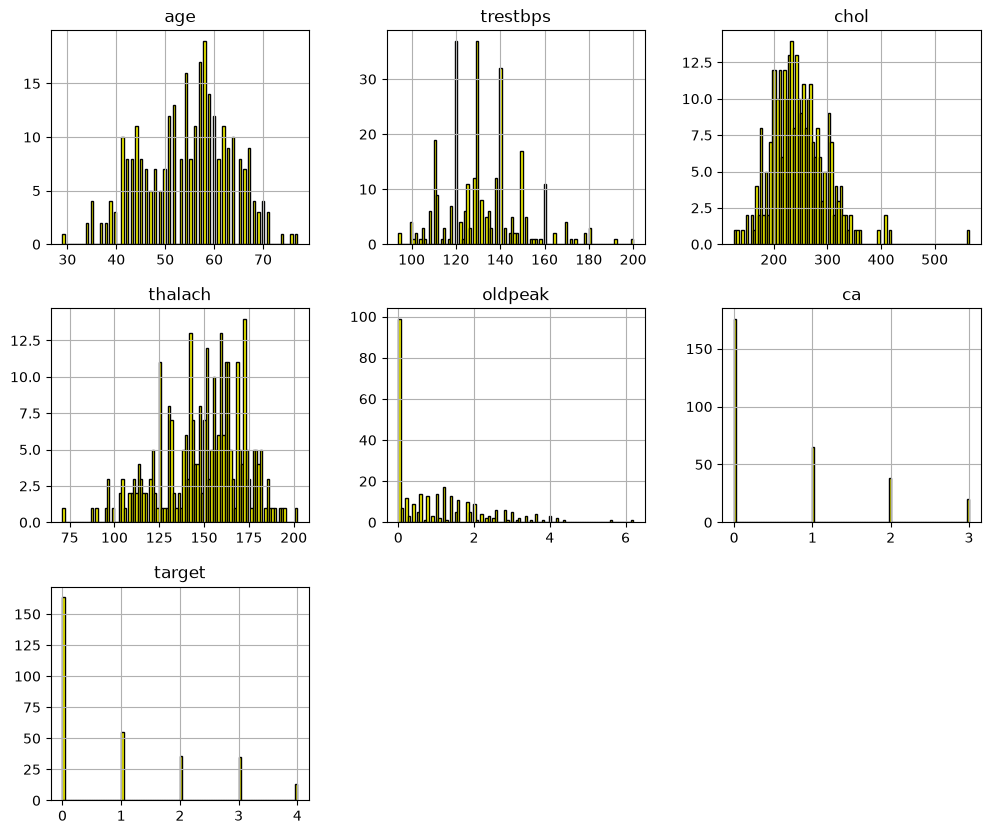

In [60]:
df.hist(figsize=(12,10), bins=100 ,color='yellow' ,edgecolor='black')
plt.show()

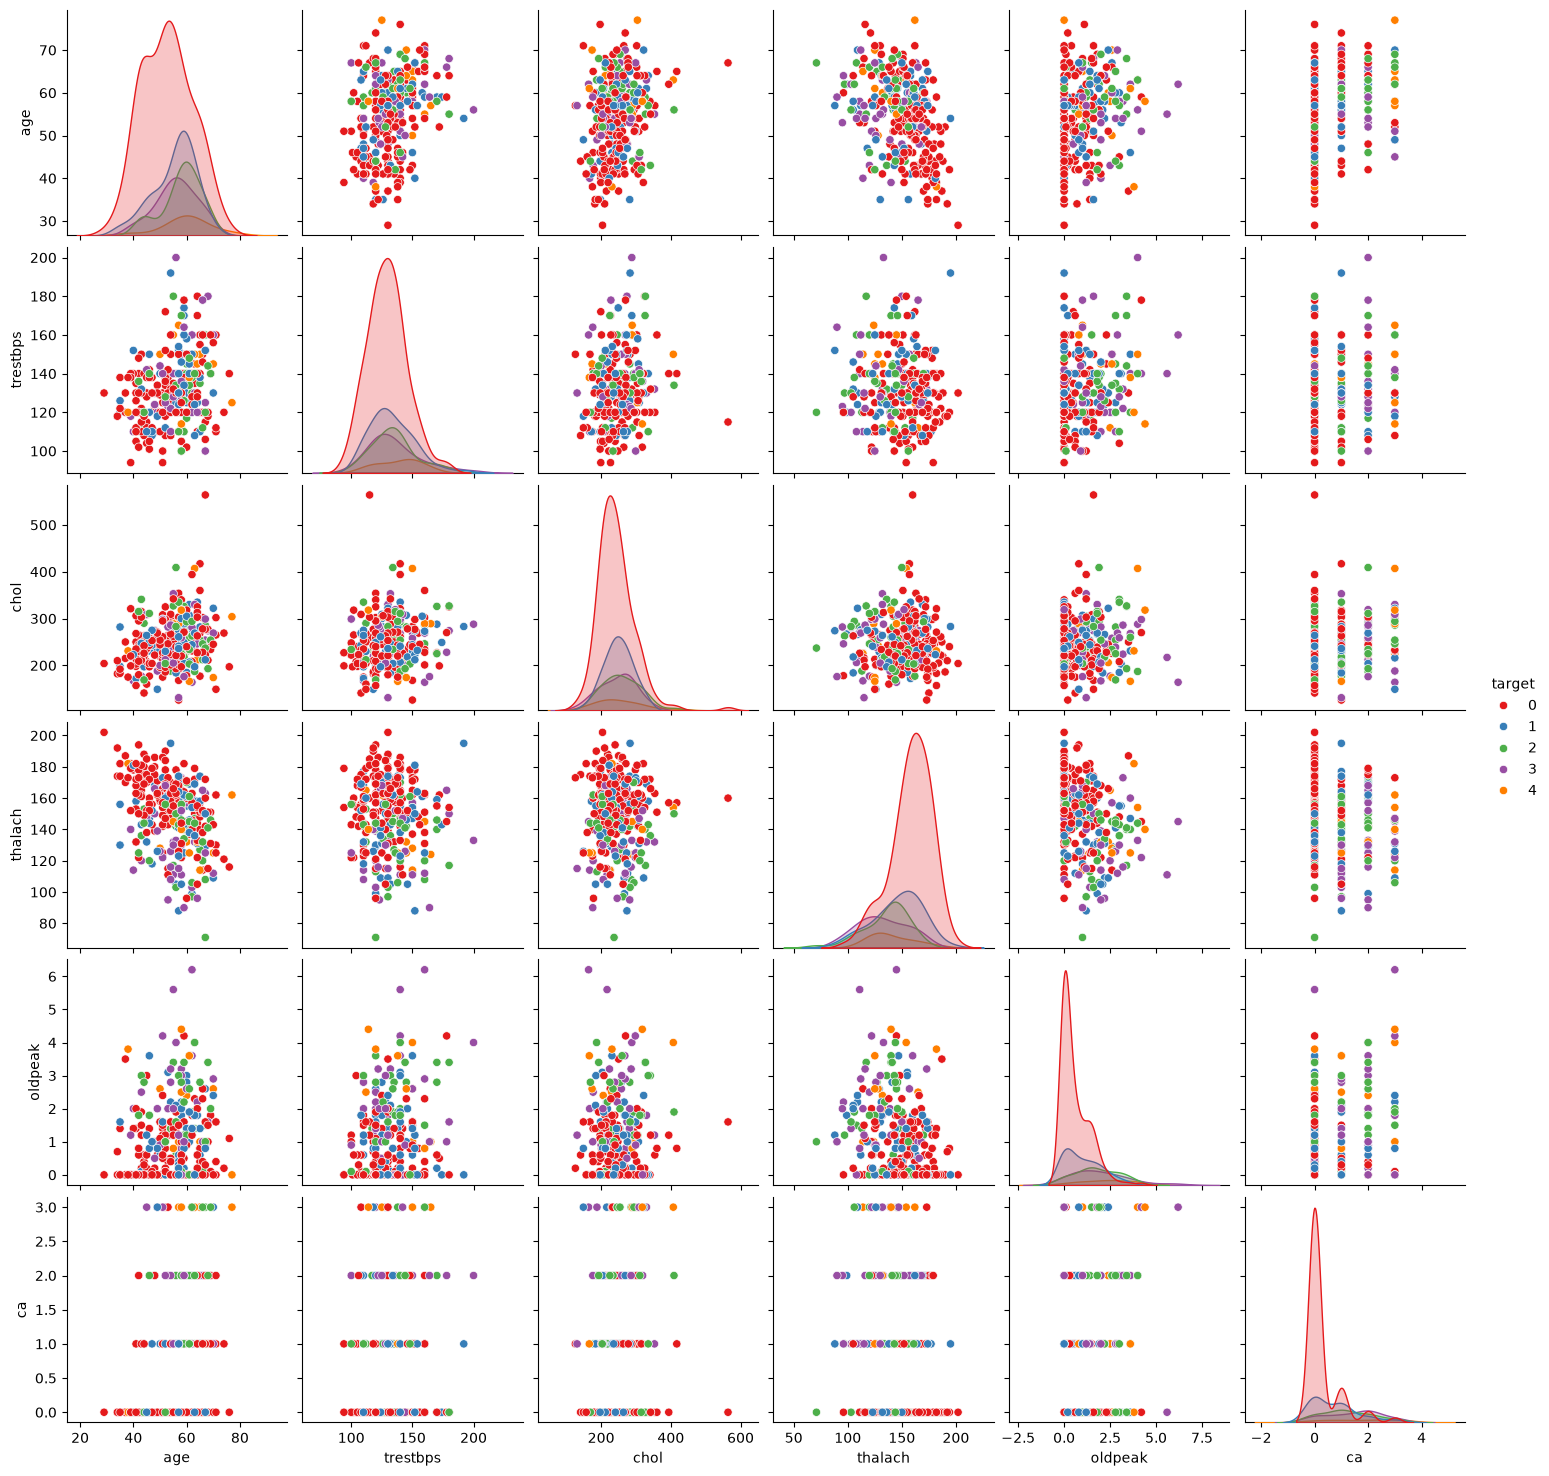

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df.select_dtypes(include=['int64', 'float64']),hue='target', palette='Set1', diag_kind='kde')
plt.show()

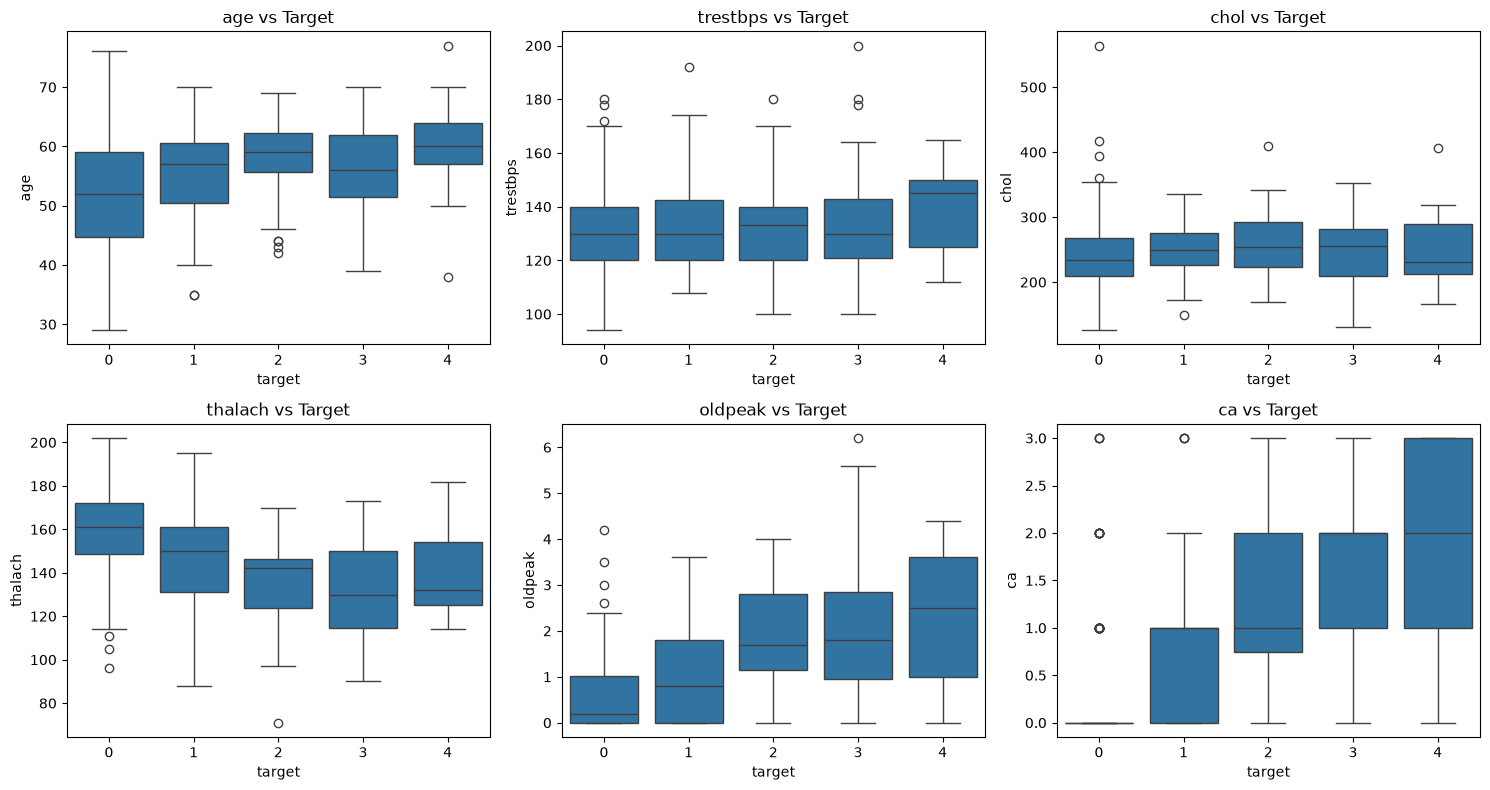

In [63]:
numeric_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, feature in zip(axes.flat, numeric_features):
    sns.boxplot(data=df, x='target', y=feature, ax=ax)
    ax.set_title(f'{feature} vs Target')

plt.tight_layout()
plt.show()